# Cell2Net Transcription Factor Activity Analysis

This tutorial demonstrates how to analyze transcription factor (TF) activity patterns across different PBMC cell types using the regulatory networks generated from Cell2Net model interpretations. By quantifying and visualizing TF activity, we can understand cell-type-specific regulatory programs and identify key transcriptional drivers of immune cell identity.

## Overview

Transcription factor activity analysis transforms the TF attribution scores from Cell2Net models into biologically interpretable activity patterns:

1. **Activity Quantification**: Aggregate TF attribution scores across target genes for each cell type
2. **Variance Analysis**: Identify TFs with cell-type-specific activity patterns
3. **Activity Visualization**: Create dotplots comparing TF activity across immune cell populations
4. **Expression Correlation**: Compare predicted TF activity with actual TF gene expression

## Biological Significance

TF activity analysis reveals:
- **Cell Identity Programs**: Which TFs define each immune cell type
- **Regulatory Specificity**: How different cell types use distinct TF combinations
- **Master Regulators**: TFs with broad influence across multiple target genes
- **Lineage Relationships**: Shared regulatory programs between related cell types

This approach bridges the gap between computational predictions and biological understanding of immune cell regulation.

In [ ]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import scanpy as sc
import mudata as md
import pandas as pd
import cell2net as cn
md.set_options(pull_on_update=False)

## 2. Load and Normalize Expression Data

Load the multiome dataset and perform standard normalization for gene expression analysis:
- **mdata.h5mu**: Multiome object containing single-cell RNA expression, ATAC accessibility, and cell annotations.
- **Total-count normalization**: Scale gene expression to 10,000 total counts per cell
- **Log transformation**: Apply log1p transformation for variance stabilization

This normalization enables comparison of TF gene expression levels across different cell types and provides a baseline for correlating predicted TF activity with actual TF expression.

In [ ]:
mdata = md.read_h5mu("./mdata.h5mu")
sc.pp.normalize_total(mdata['rna'])
sc.pp.log1p(mdata['rna'])

## 3. Load TF-Gene Regulatory Network

Load the  TF-gene regulatory network generated from Cell2Net model interpretations in last step:
- **tf_to_gene.csv**: Attribution-based regulatory relationships from previous tutorial step
- **Network structure**: Contains TF names, target genes, cell types, and attribution scores
- **Quantitative measures**: Mean attribution scores represent regulatory strength

This dataset provides the foundation for computing TF activity by aggregating regulatory impact across all target genes for each transcription factor.

In [ ]:
df = pd.read_csv("./05_tf_to_gene/tf_to_gene.csv", 
                 index_col=0)

In [28]:
df

,tf,gene,cell_type_v2,mean_attr,std_attr
0,KLF2,ISG15,B cell,1.415844,0.468231
1,ELF1,ISG15,B cell,0.975179,0.298402
2,MEF2C,ISG15,B cell,0.851608,0.448217
3,IKZF3,ISG15,B cell,0.699268,0.239014
4,JUNB,ISG15,B cell,0.691353,0.323894
...,...,...,...,...,...
75,ARID3A,CLIC2,pDC,0.167850,0.062825
76,MAX,CLIC2,pDC,0.154308,0.050194
77,CREB3L2,CLIC2,pDC,0.151772,0.049553
78,MGA,CLIC2,pDC,0.150544,0.062157


## 4. Compute TF Activity Scores

Calculate transcription factor activity by aggregating attribution scores across target genes:

### Activity Computation Process
1. **Group by TF and cell type**: Organize regulatory relationships by transcription factor and cellular context
2. **Sum attributions**: Aggregate mean attribution scores across all target genes for each TF
3. **Pivot table**: Reshape data with TFs as rows and cell types as columns
4. **Fill missing values**: Set activity to 0 for TF-cell type combinations without regulatory targets

### Biological Interpretation
- **High activity scores**: TFs with strong regulatory impact across many target genes
- **Cell-type specificity**: Different activity patterns reveal regulatory specialization
- **Regulatory breadth**: TFs with activity across multiple cell types may be master regulators
- **Context dependence**: Same TF can have different activity levels in different immune cells

The resulting activity matrix provides a quantitative, cell-type-resolved view of transcriptional regulation learned by Cell2Net models.

In [29]:
# get average regulation of each tf within cell types
df_act = df.groupby(['tf', 'cell_type_v2'])['mean_attr'].sum().reset_index()
df_act = df_act.pivot_table(index='tf', columns='cell_type_v2', values='mean_attr')
df_act = df_act.fillna(0)
df_act = df_act.rename_axis(None, axis=0)
df_act = df_act.rename_axis(None, axis=1)

In [30]:
df_act

,B cell,Effector T cell,Memory T cell,Monocyte,NK cell,Naive T cell,cDC,pDC
ARID3A,0.848500,0.000000,0.000000,4.606098,0.000000,0.023151,1.556543,72.943250
ARID3B,0.040328,0.358864,0.245848,0.000000,0.391047,0.131400,0.000000,0.071191
ARID5A,0.000000,0.000000,0.000000,0.000000,0.157263,0.000000,0.124857,0.000000
ARNT,1.845523,1.301548,1.280509,2.056258,2.019301,1.109258,1.659010,2.303763
ARNTL,0.000000,3.020990,2.020507,0.073984,7.520797,0.000000,0.000000,0.086325
...,...,...,...,...,...,...,...,...
ZNF740,0.069531,0.072358,0.051780,0.000000,0.069313,0.067072,0.000000,0.000000
ZNF75A,0.153219,0.354103,0.134158,0.000000,0.152452,0.683735,0.000000,0.000000
ZNF76,0.038586,0.054669,0.078891,0.063455,0.045685,0.100084,0.041894,0.000000
ZNF766,0.279524,0.000000,0.156850,0.000000,0.045424,0.278122,0.065266,0.000000


## 5. Analyze TF Activity Variance

Visualize transcription factor activity variance across cell types to identify the most cell-type-specific regulators:

### Variance Analysis
- **Activity variance**: Measures how much TF activity differs across cell types
- **Cell-type specificity**: High variance indicates specialized regulatory roles
- **Master regulators**: Moderate variance may suggest broad regulatory influence
- **Top variable TFs**: Display the 5 most cell-type-specific transcription factors

### Biological Interpretation
- **High variance TFs**: Likely define cell identity and lineage-specific programs
- **Consistent activity**: May represent housekeeping or broadly required regulatory functions
- **Regulatory specialization**: Cell-type-specific TFs drive functional diversification

This analysis helps prioritize transcription factors for detailed biological investigation and experimental validation.

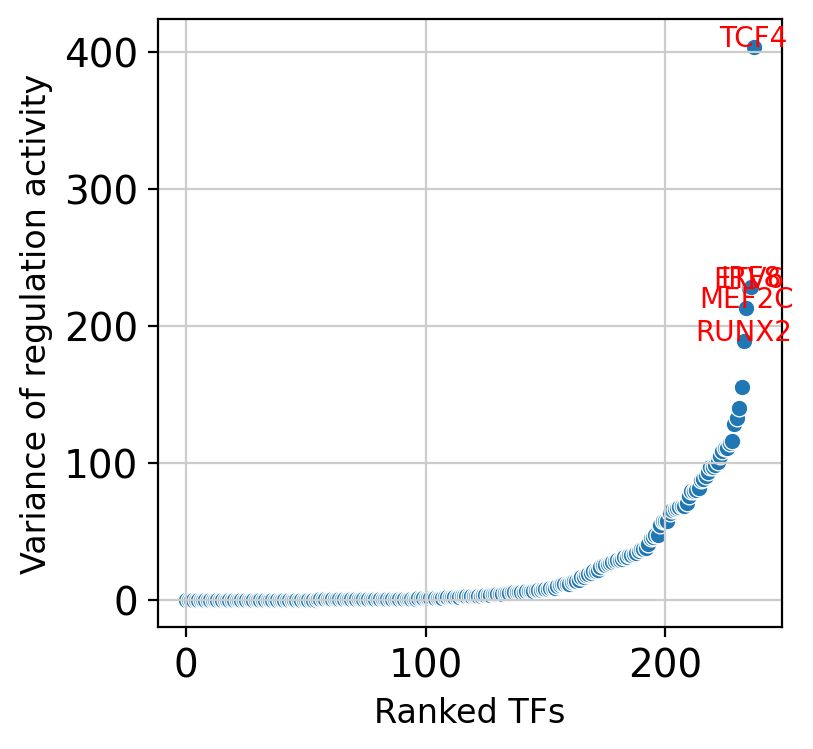

In [31]:
cn.pl.tf_activity_variance(df_act, n_labels=5)

## 6. Select Top Variable TFs for Visualization

Identify the most cell-type-specific transcription factors for detailed visualization:

### Selection Criteria
- **n_top_tfs=5**: Select top 5 TFs for each cell type based on activity levels
- **var_cutoff=0.3**: Require minimum variance across cell types to ensure specificity
- **Cell-type resolution**: Identify key regulators for each immune cell population

### Output Structure
The `var_names` dictionary organizes selected TFs by cell type, enabling focused visualization of:
- **Cell identity TFs**: Key regulators that define each immune cell type
- **Regulatory programs**: TF combinations that drive cell-type-specific functions
- **Lineage markers**: Transcription factors associated with immune cell differentiation

This curated selection focuses subsequent analysis on the most biologically relevant and cell-type-specific regulatory relationships.

In [32]:
df_top_tfs = cn.ip.get_top_tfs(df_act, n_top_tfs=5, var_cutoff=0.3)
var_names = df_top_tfs.to_dict(orient="list")

### Inspect Selected TFs by Cell Type

Display the selected transcription factors organized by immune cell type. This curated list represents the most cell-type-specific and highly active TFs identified from Cell2Net regulatory network analysis, providing focused targets for biological interpretation and experimental validation.

In [33]:
var_names

{'B cell': ['PAX5', 'SOX5', 'EBF1', 'BACH2', 'IKZF3'],
 'Effector T cell': ['IKZF2', 'RORA', 'KLF12', 'STAT4', 'RUNX1'],
 'Memory T cell': ['STAT5B', 'RORA', 'ETS1', 'RUNX1', 'BCL11B'],
 'Monocyte': ['TCF7L2', 'FOXO3', 'BACH1', 'STAT1', 'IRF1'],
 'NK cell': ['BNC2', 'NFATC2', 'KLF13', 'RUNX3', 'NFATC3'],
 'Naive T cell': ['LEF1', 'TCF7', 'FOXP1', 'FOXO1', 'BCL11B'],
 'cDC': ['RBPJ', 'JUND', 'SPI1', 'CEBPD', 'NR4A2'],
 'pDC': ['CUX2', 'IRF7', 'IRF4', 'ARID3A', 'TCF4']}

## 7. Visualize TF Gene Expression

Create a dotplot showing actual transcription factor gene expression across PBMC cell types:

### Visualization Features
- **Dotplot format**: Dot size represents expression level, color represents average expression
- **Standard scaling**: Normalize expression values across cell types for comparison
- **Dendrogram**: Hierarchical clustering reveals cell type relationships
- **Gene organization**: TFs grouped by cell type for systematic comparison

### Biological Context
This expression analysis provides a baseline for comparing:
- **TF availability**: Whether TFs are expressed in cells where they show predicted activity
- **Expression vs. activity**: How TF gene expression correlates with regulatory activity
- **Cell-type patterns**: Which cell types express specific lineage-determining TFs
- **Regulatory potential**: High expression may enable strong regulatory impact

The expression patterns help validate Cell2Net predictions and identify cases where post-transcriptional regulation may modulate TF activity.

2025-11-24 01:15:55 INFO     maxp pruned
2025-11-24 01:15:55 INFO     cmap pruned
2025-11-24 01:15:55 INFO     kern dropped
2025-11-24 01:15:55 INFO     post pruned
2025-11-24 01:15:55 INFO     FFTM dropped
2025-11-24 01:15:55 INFO     GPOS pruned
2025-11-24 01:15:55 INFO     GSUB pruned
2025-11-24 01:15:56 INFO     glyf pruned
2025-11-24 01:15:56 INFO     Added gid0 to subset
2025-11-24 01:15:56 INFO     Added first four glyphs to subset
2025-11-24 01:15:56 INFO     Closing glyph list over 'MATH': 56 glyphs before
2025-11-24 01:15:56 INFO     Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'X', 'Z', 'a', 'c', 'e', 'eight', 'f', 'five', 'four', 'g', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'parenleft', 'parenright', 'percent', 'period', 'r', 's', 'seven', 'six', 'space', 't', 'three', 'two', 'u', 'v', 'x', 'y', 'zero']
2025-11-24 01:15:56 INFO     Glyph IDs:   [0, 1, 2, 3, 8, 11, 12, 17, 19

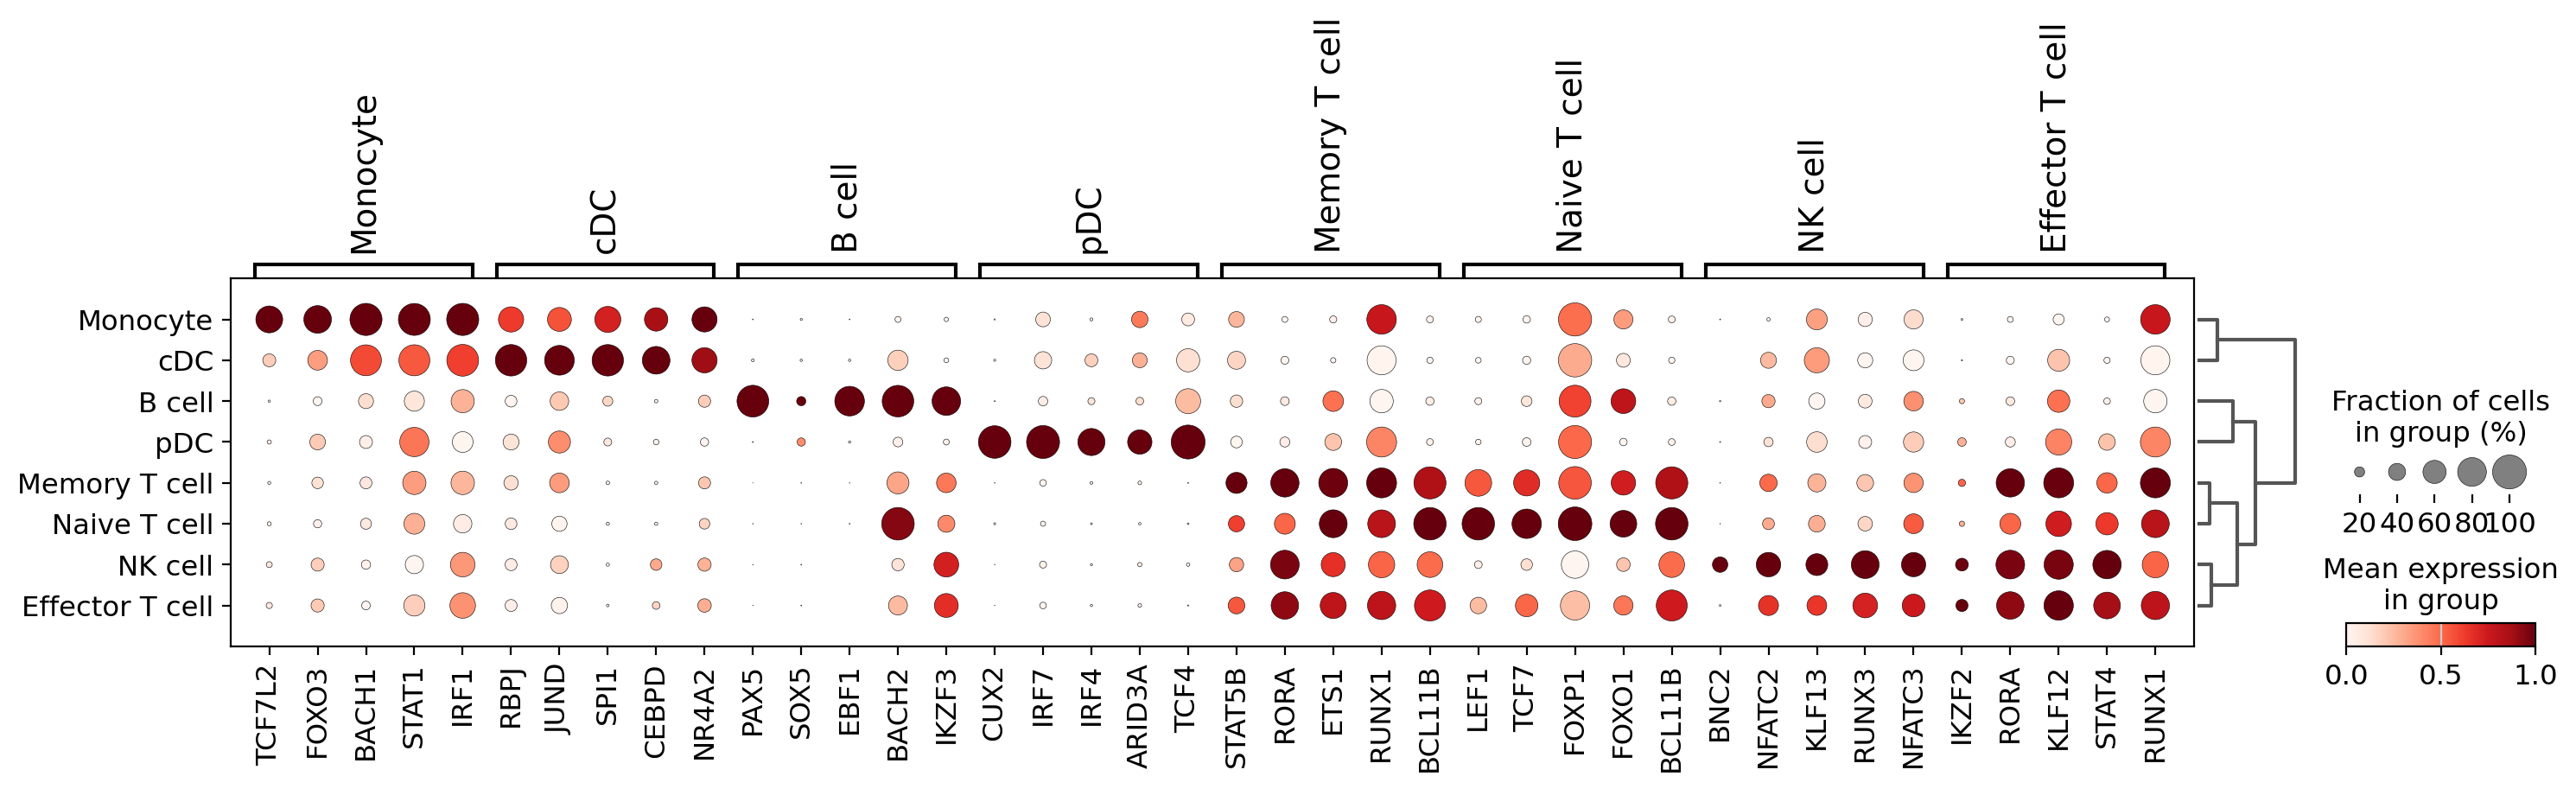

In [34]:
sc.pl.dotplot(mdata['rna'], groupby="cell_type_v2", 
              var_names=var_names,
              standard_scale='var', dendrogram=True, swap_axes=False, 
              save="tf_expression.pdf")

## 8. Visualize TF Regulatory Activity

Create a specialized dotplot showing Cell2Net-predicted transcription factor regulatory activity:

### Activity Visualization Features
- **Custom TF dotplot**: Specialized visualization for regulatory activity data
- **Green colormap**: Intuitive color scheme for activity levels
- **Cell type ordering**: Organized by immune cell lineage relationships
- **Standard scaling**: Normalized activity scores for cross-TF comparison
- **Target filtering**: Focus on TFs with 0-200 target genes for interpretability

### Activity vs. Expression Comparison
This activity plot complements the expression analysis by showing:
- **Regulatory impact**: How strongly TFs regulate their target genes
- **Cell-type specificity**: Where each TF exerts its strongest regulatory influence
- **Functional activity**: Regulatory strength independent of expression level
- **Network-derived insights**: Activity patterns learned from multiome data integration

### Biological Interpretation
- **High activity**: TFs with strong regulatory control in specific cell types
- **Activity patterns**: Cell-type-specific regulatory programs
- **Master regulators**: TFs with broad activity across multiple cell types
- **Regulatory modules**: Co-active TFs that may work together in regulatory complexes

The comparison between expression and activity patterns reveals the complex relationship between TF availability and regulatory function in immune cells.

2025-11-24 01:15:57 INFO     maxp pruned
2025-11-24 01:15:57 INFO     cmap pruned
2025-11-24 01:15:57 INFO     kern dropped
2025-11-24 01:15:57 INFO     post pruned
2025-11-24 01:15:57 INFO     FFTM dropped
2025-11-24 01:15:57 INFO     GPOS pruned
2025-11-24 01:15:57 INFO     GSUB pruned
2025-11-24 01:15:57 INFO     glyf pruned
2025-11-24 01:15:57 INFO     Added gid0 to subset
2025-11-24 01:15:57 INFO     Added first four glyphs to subset
2025-11-24 01:15:57 INFO     Closing glyph list over 'MATH': 51 glyphs before
2025-11-24 01:15:57 INFO     Glyph names: ['.notdef', '.null', 'A', 'B', 'C', 'D', 'E', 'F', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'R', 'S', 'T', 'U', 'X', 'Z', 'a', 'b', 'c', 'e', 'f', 'five', 'four', 'g', 'i', 'l', 'm', 'n', 'nonmarkingreturn', 'o', 'one', 'p', 'period', 'r', 's', 'seven', 'space', 't', 'three', 'two', 'u', 'v', 'y', 'zero']
2025-11-24 01:15:57 INFO     Glyph IDs:   [0, 1, 2, 3, 17, 19, 20, 21, 22, 23, 24, 26, 36, 37, 38, 39, 40, 41, 43, 44, 45, 46,

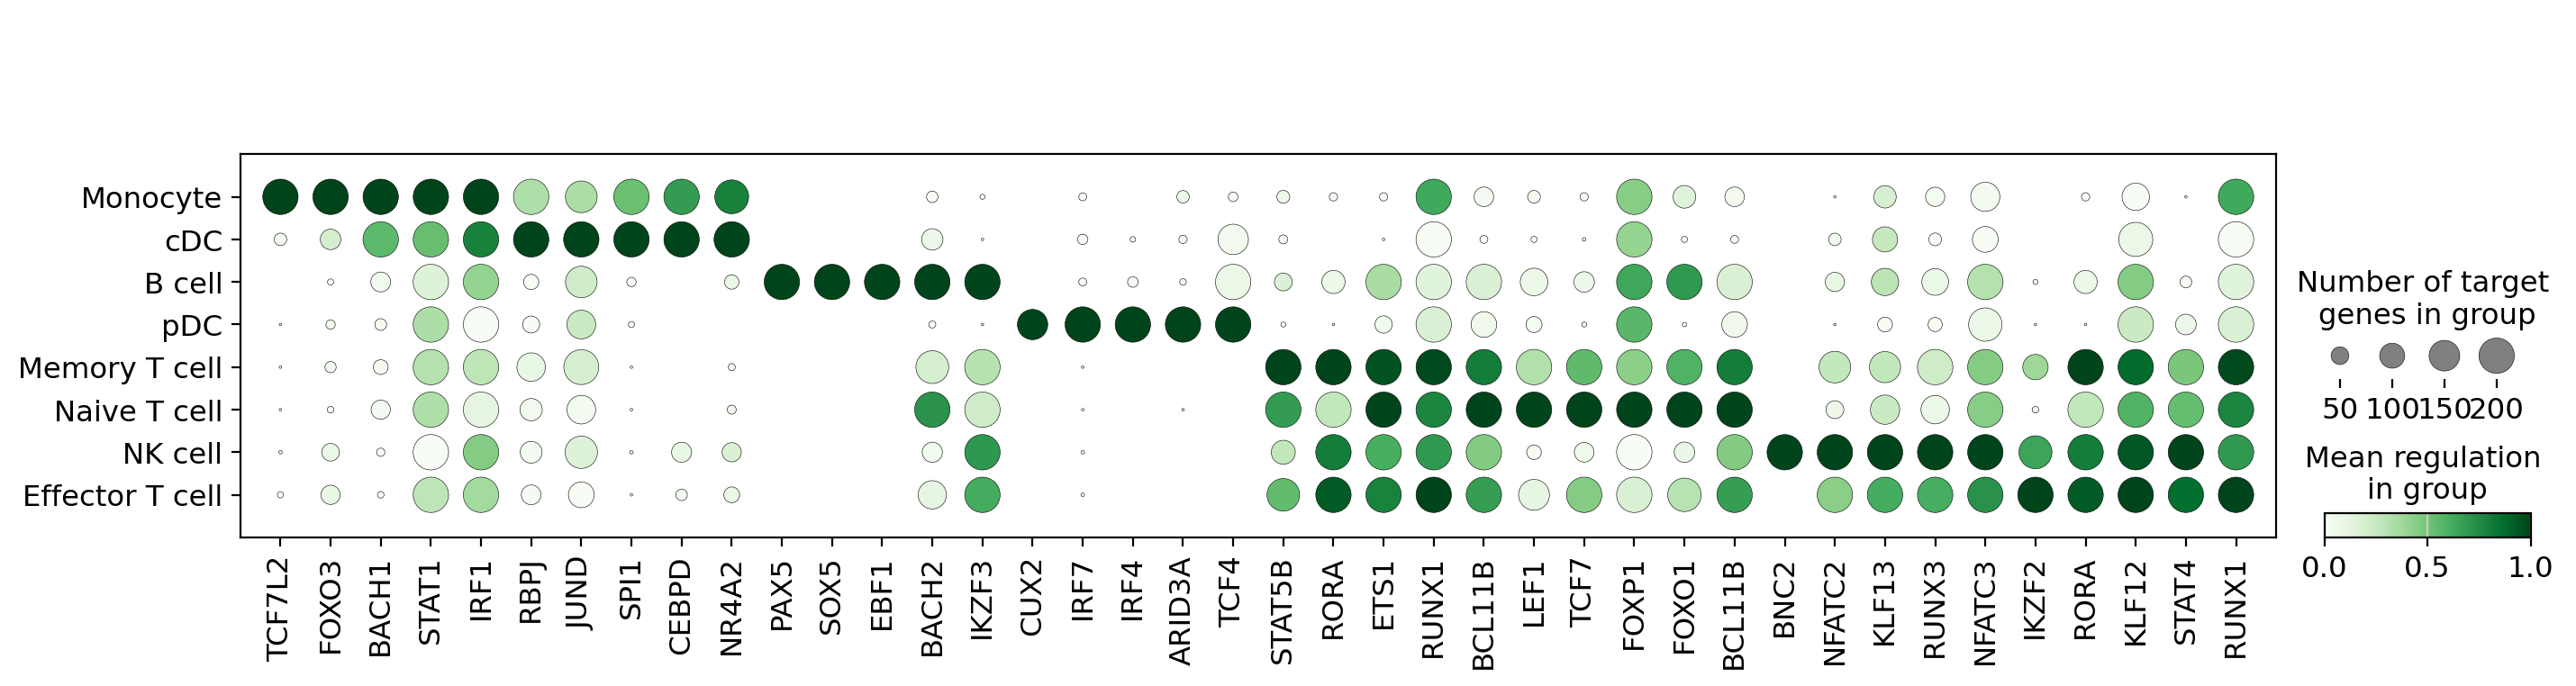

In [35]:
cn.pl.tf_dotplot(df, 
                 group_col="cell_type_v2", 
                 activity_col="mean_attr",
                 var_names=var_names, cmap="Greens",
                 categories_order=['Monocyte', 'cDC', 'B cell', 'pDC', 'Memory T cell', 'Naive T cell',
                                   'NK cell', 'Effector T cell'],
                 standard_scale="var", n_targets_min=0, n_targets_max=200,
                 save="tf_activity.pdf")